# Alabama Counties: GRIDMET vs NLDAS3 Climatology Comparison

This notebook compares monthly county-level climatology for Alabama:
- Mean GDD by county and month
- Standard deviation (interannual variability) by county and month
- Pearson and Spearman correlation
- Distribution comparison and monthly cycle

In [ ]:
# Uncomment if needed
# %pip install geopandas rasterio rasterstats scipy seaborn matplotlib pandas numpy

In [2]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
from rasterstats import zonal_stats
from scipy.stats import pearsonr, spearmanr

In [28]:
# ------------------------------
# Paths and settings
# ------------------------------
gridmet_dir = Path("./gridmet-data/climatalogy")
nldas_dir = Path("./nldas3-data/climatology")

# Band mapping for each variable/stat in monthly climatology GeoTIFFs
BANDS = {
    "gdd": {"mean": 1, "std": 4},
    "hsd": {"mean": 2, "std": 5},
    "frost_days": {"mean": 3, "std": 6},
}

for m in range(1, 13):
    g_file = gridmet_dir / f"GRIDMET_Climatology_Month_{m:02d}.tif"
    n_file = nldas_dir / f"NLDAS3_Climatology_Month_{m:02d}.tif"
    if not g_file.exists():
        raise FileNotFoundError(f"Missing GRIDMET file: {g_file}")
    if not n_file.exists():
        raise FileNotFoundError(f"Missing NLDAS3 file: {n_file}")

print("All monthly files found.")
print("Variables configured:", list(BANDS.keys()))

All monthly files found.
Variables configured: ['gdd', 'hsd', 'frost_days']


In [4]:
# ------------------------------
# Alabama counties (Census TIGER)
# ------------------------------
tiger_county_url = "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"
counties = gpd.read_file(tiger_county_url)
al = counties[counties["STATEFP"] == "01"].copy()
al = al.to_crs("EPSG:4326")
al = al[["GEOID", "NAME", "geometry"]].rename(columns={"NAME": "county"})

print(f"Alabama counties loaded: {len(al)}")
al.head()

Alabama counties loaded: 67


,GEOID,county,geometry
12,01027,Clay,"POLYGON ((-85.97876 33.32813, -85.97854 33.332..."
32,01091,Marengo,"POLYGON ((-87.8053 31.99046, -87.81685 31.9905..."
45,01049,DeKalb,"POLYGON ((-85.74409 34.28485, -85.74785 34.281..."
205,01019,Cherokee,"POLYGON ((-85.84387 34.23703, -85.84386 34.237..."
244,01065,Hale,"POLYGON ((-87.5252 32.65366, -87.52523 32.6404..."


In [29]:
# ------------------------------
# Zonal stats by county for each month (all variables)
# ------------------------------
rows = []
counties_base = al.reset_index(drop=True).copy()

def _clean_geom(geom):
    if geom is None or geom.is_empty:
        return None
    if not geom.is_valid:
        geom = geom.buffer(0)
    return geom if (geom is not None and not geom.is_empty) else None

def _safe_zonal_mean(geom, raster_path, band, nodata):
    try:
        stat = zonal_stats(
            [geom],
            str(raster_path),
            band=band,
            stats=["mean"],
            nodata=nodata,
            boundless=True,
            all_touched=True,
        )[0]
        return stat.get("mean", np.nan)
    except ValueError:
        # Handles rasterstats/rasterio edge cases like zero-sized windows on boundaries.
        return np.nan

for month in range(1, 13):
    gridmet_tif = gridmet_dir / f"GRIDMET_Climatology_Month_{month:02d}.tif"
    nldas_tif = nldas_dir / f"NLDAS3_Climatology_Month_{month:02d}.tif"

    with rasterio.open(gridmet_tif) as src_g:
        g_crs = src_g.crs
        g_nodata = src_g.nodata

    with rasterio.open(nldas_tif) as src_n:
        n_crs = src_n.crs
        n_nodata = src_n.nodata

    counties_g = counties_base.to_crs(g_crs) if counties_base.crs != g_crs else counties_base
    counties_n = counties_base.to_crs(n_crs) if counties_base.crs != n_crs else counties_base

    for i, county_row in counties_base.iterrows():
        geom_g = _clean_geom(counties_g.geometry.iloc[i])
        geom_n = _clean_geom(counties_n.geometry.iloc[i])

        row = {
            "month": month,
            "GEOID": county_row["GEOID"],
            "county": county_row["county"],
        }

        for var, band_map in BANDS.items():
            g_mean = _safe_zonal_mean(geom_g, gridmet_tif, band_map["mean"], g_nodata) if geom_g is not None else np.nan
            n_mean = _safe_zonal_mean(geom_n, nldas_tif, band_map["mean"], n_nodata) if geom_n is not None else np.nan
            g_std = _safe_zonal_mean(geom_g, gridmet_tif, band_map["std"], g_nodata) if geom_g is not None else np.nan
            n_std = _safe_zonal_mean(geom_n, nldas_tif, band_map["std"], n_nodata) if geom_n is not None else np.nan

            row[f"gridmet_{var}_mean"] = g_mean
            row[f"nldas3_{var}_mean"] = n_mean
            row[f"gridmet_{var}_std"] = g_std
            row[f"nldas3_{var}_std"] = n_std

        rows.append(row)

df = pd.DataFrame(rows)
df.head()

,month,GEOID,county,gridmet_gdd_mean,nldas3_gdd_mean,gridmet_gdd_std,nldas3_gdd_std,gridmet_hsd_mean,nldas3_hsd_mean,gridmet_hsd_std,nldas3_hsd_std,gridmet_frost_days_mean,nldas3_frost_days_mean,gridmet_frost_days_std,nldas3_frost_days_std
0,1,01027,Clay,26.997431,34.139031,21.722118,25.455258,0.0,0.0,0.0,0.0,19.039726,13.204602,4.492669,5.008688
1,1,01091,Marengo,44.400264,56.510259,33.243514,35.586799,0.0,0.0,0.0,0.0,14.596476,9.768745,4.578968,5.363067
2,1,01049,DeKalb,19.603990,22.132162,18.918170,20.219438,0.0,0.0,0.0,0.0,18.557513,16.265144,5.140594,5.806938
3,1,01019,Cherokee,22.883490,28.569229,20.999585,23.634816,0.0,0.0,0.0,0.0,18.211409,12.723466,5.237756,4.898515
4,1,01065,Hale,41.280598,50.642384,32.235481,33.683299,0.0,0.0,0.0,0.0,14.750898,10.421786,4.889589,5.291043


In [19]:
# ------------------------------
# Correlation summary (all county-month pairs)
# ------------------------------
valid_mean = df[["gridmet_gdd_mean", "nldas3_gdd_mean"]].dropna()
valid_std = df[["gridmet_gdd_std", "nldas3_gdd_std"]].dropna()

summary_rows = []

if len(valid_mean) >= 2:
    pearson_mean = pearsonr(valid_mean["gridmet_gdd_mean"], valid_mean["nldas3_gdd_mean"])
    spearman_mean = spearmanr(valid_mean["gridmet_gdd_mean"], valid_mean["nldas3_gdd_mean"])
    summary_rows.append({
        "metric": "GDD mean",
        "n_pairs": len(valid_mean),
        "pearson_r": pearson_mean.statistic,
        "pearson_p": pearson_mean.pvalue,
        "spearman_rho": spearman_mean.statistic,
        "spearman_p": spearman_mean.pvalue,
    })
else:
    summary_rows.append({
        "metric": "GDD mean",
        "n_pairs": len(valid_mean),
        "pearson_r": np.nan,
        "pearson_p": np.nan,
        "spearman_rho": np.nan,
        "spearman_p": np.nan,
    })

if len(valid_std) >= 2:
    pearson_std = pearsonr(valid_std["gridmet_gdd_std"], valid_std["nldas3_gdd_std"])
    spearman_std = spearmanr(valid_std["gridmet_gdd_std"], valid_std["nldas3_gdd_std"])
    summary_rows.append({
        "metric": "GDD std",
        "n_pairs": len(valid_std),
        "pearson_r": pearson_std.statistic,
        "pearson_p": pearson_std.pvalue,
        "spearman_rho": spearman_std.statistic,
        "spearman_p": spearman_std.pvalue,
    })
else:
    summary_rows.append({
        "metric": "GDD std",
        "n_pairs": len(valid_std),
        "pearson_r": np.nan,
        "pearson_p": np.nan,
        "spearman_rho": np.nan,
        "spearman_p": np.nan,
    })

summary = pd.DataFrame(summary_rows)
if (summary["n_pairs"] < 2).any():
    print("Warning: insufficient overlapping non-null GRIDMET/NLDAS3 county values for some metrics.")

summary

,metric,n_pairs,pearson_r,pearson_p,spearman_rho,spearman_p
0,GDD mean,804,0.996450,0.000000e+00,0.996435,0.000000e+00
1,GDD std,804,0.808727,4.909904e-187,0.806165,5.791855e-185


In [20]:
# ------------------------------
# Correlation by month
# ------------------------------
corr_rows = []
for month, g in df.groupby("month"):
    m = g[["gridmet_gdd_mean", "nldas3_gdd_mean"]].dropna()
    s = g[["gridmet_gdd_std", "nldas3_gdd_std"]].dropna()

    corr_rows.append({
        "month": month,
        "pearson_mean": pearsonr(m["gridmet_gdd_mean"], m["nldas3_gdd_mean"]).statistic if len(m) > 2 else np.nan,
        "spearman_mean": spearmanr(m["gridmet_gdd_mean"], m["nldas3_gdd_mean"]).statistic if len(m) > 2 else np.nan,
        "pearson_std": pearsonr(s["gridmet_gdd_std"], s["nldas3_gdd_std"]).statistic if len(s) > 2 else np.nan,
        "spearman_std": spearmanr(s["gridmet_gdd_std"], s["nldas3_gdd_std"]).statistic if len(s) > 2 else np.nan,
    })

corr_month = pd.DataFrame(corr_rows).sort_values("month")
corr_month

,month,pearson_mean,spearman_mean,pearson_std,spearman_std
0,1,0.987003,0.990302,0.967917,0.972743
1,2,0.984006,0.987908,0.961393,0.980166
2,3,0.982643,0.988786,0.956066,0.959454
3,4,0.975160,0.979208,0.863013,0.870261
4,5,0.962139,0.966478,0.456278,0.470828
5,6,0.913692,0.927089,-0.487900,-0.531248
6,7,0.813538,0.845000,0.651443,0.581251
7,8,0.898285,0.906617,0.834764,0.844042
8,9,0.930618,0.947043,0.860811,0.849350
9,10,0.963401,0.975257,-0.219053,-0.178546


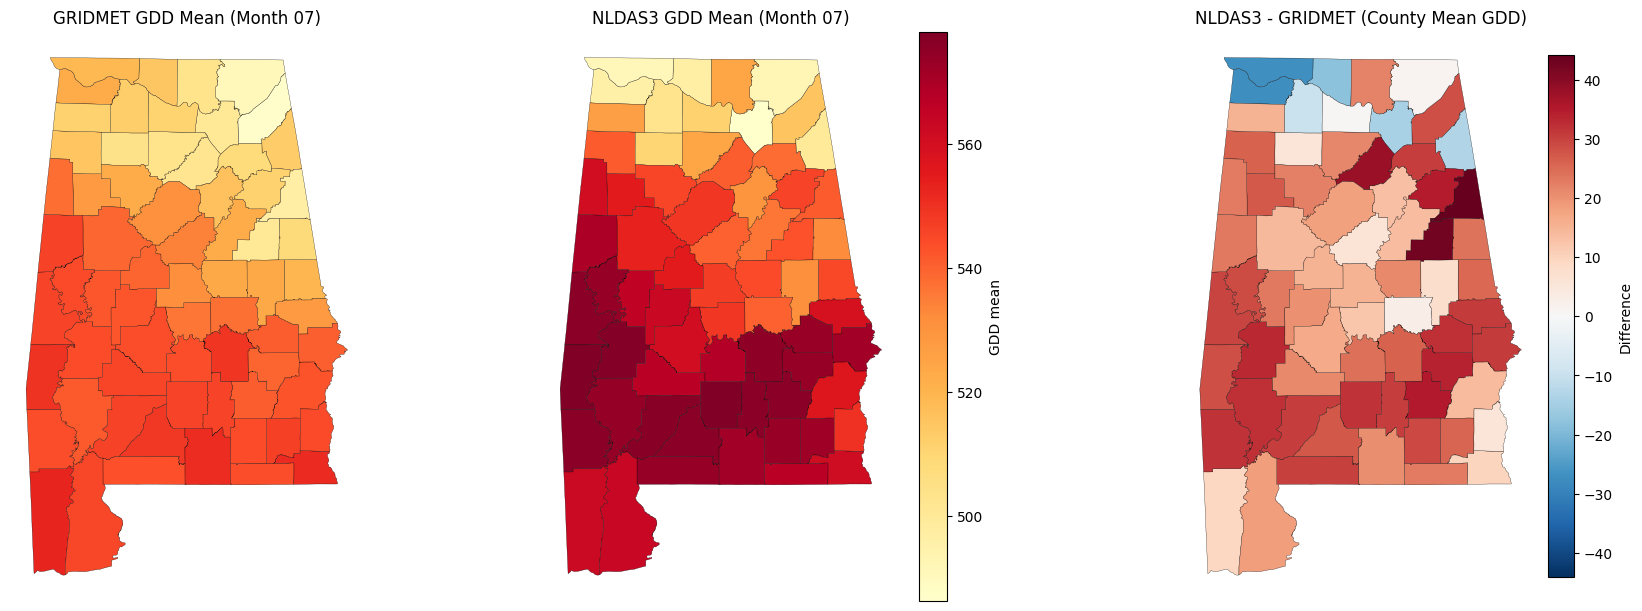

In [24]:
# ------------------------------
# Maps: county mean GDD comparison for one month (shared color scale for first two panels)
# ------------------------------
import matplotlib as mpl

plot_month = 7
m_df = df[df["month"] == plot_month].copy()
map_df = al.merge(m_df, on=["GEOID", "county"], how="left")
map_df["diff_mean"] = map_df["nldas3_gdd_mean"] - map_df["gridmet_gdd_mean"]

# Shared range for GRIDMET and NLDAS panels
shared_min = np.nanmin([map_df["gridmet_gdd_mean"].min(), map_df["nldas3_gdd_mean"].min()])
shared_max = np.nanmax([map_df["gridmet_gdd_mean"].max(), map_df["nldas3_gdd_mean"].max()])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

map_df.plot(
    column="gridmet_gdd_mean", ax=axes[0], legend=False, cmap="YlOrRd",
    vmin=shared_min, vmax=shared_max, edgecolor="black", linewidth=0.2
 )
axes[0].set_title(f"GRIDMET GDD Mean (Month {plot_month:02d})")
axes[0].axis("off")

map_df.plot(
    column="nldas3_gdd_mean", ax=axes[1], legend=False, cmap="YlOrRd",
    vmin=shared_min, vmax=shared_max, edgecolor="black", linewidth=0.2
 )
axes[1].set_title(f"NLDAS3 GDD Mean (Month {plot_month:02d})")
axes[1].axis("off")

# Shared colorbar for first two panels
norm_shared = mpl.colors.Normalize(vmin=shared_min, vmax=shared_max)
sm_shared = mpl.cm.ScalarMappable(norm=norm_shared, cmap="YlOrRd")
sm_shared.set_array([])
cbar_shared = fig.colorbar(sm_shared, ax=[axes[0], axes[1]], fraction=0.035, pad=0.02)
cbar_shared.set_label("GDD mean")

# Difference panel with its own diverging color scale
diff_max_abs = np.nanmax(np.abs(map_df["diff_mean"]))
map_df.plot(
    column="diff_mean", ax=axes[2], legend=False, cmap="RdBu_r",
    vmin=-diff_max_abs, vmax=diff_max_abs, edgecolor="black", linewidth=0.2
 )
axes[2].set_title("NLDAS3 - GRIDMET (County Mean GDD)")
axes[2].axis("off")
norm_diff = mpl.colors.Normalize(vmin=-diff_max_abs, vmax=diff_max_abs)
sm_diff = mpl.cm.ScalarMappable(norm=norm_diff, cmap="RdBu_r")
sm_diff.set_array([])
cbar_diff = fig.colorbar(sm_diff, ax=axes[2], fraction=0.05, pad=0.02)
cbar_diff.set_label("Difference")

plt.show()

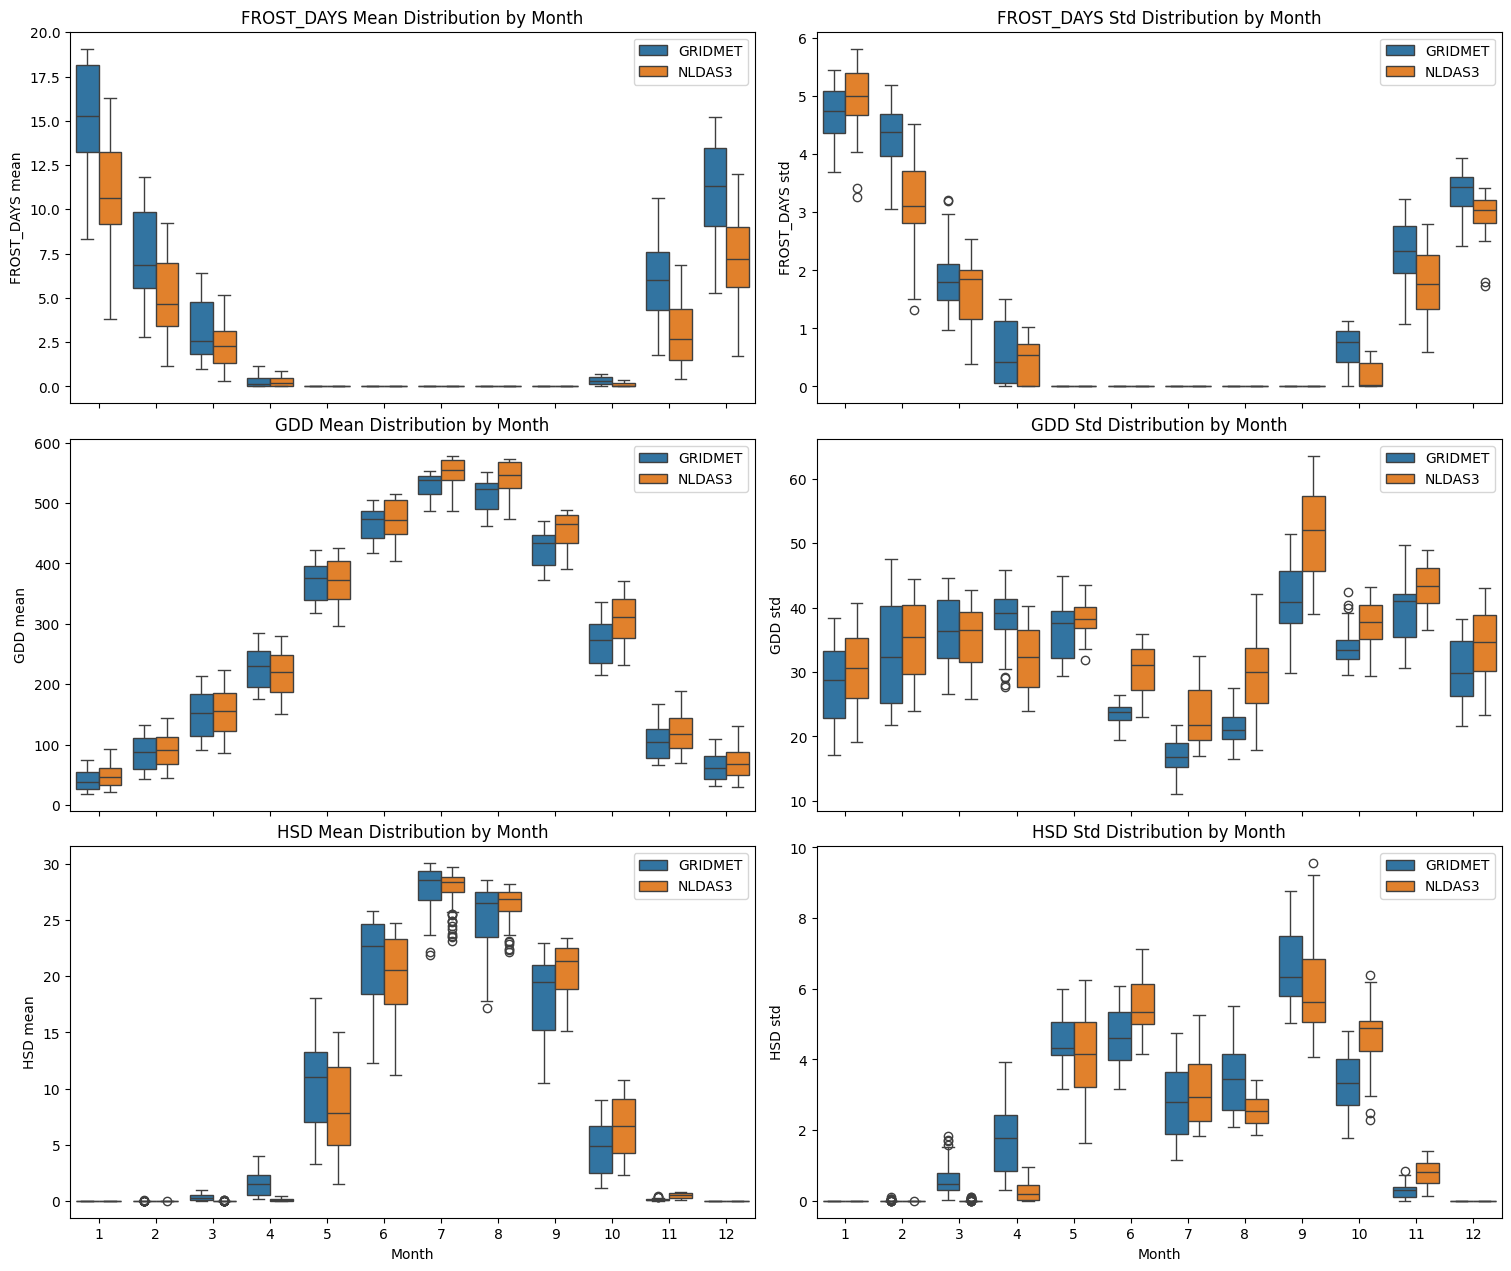

In [35]:
# ------------------------------
# Distribution comparison by month (all variables)
# ------------------------------
value_cols = [
    c for c in df.columns
    if (c.startswith("gridmet_") or c.startswith("nldas3_")) and (c.endswith("_mean") or c.endswith("_std"))
]

plot_df = df.melt(
    id_vars=["month", "GEOID", "county"],
    value_vars=value_cols,
    var_name="series",
    value_name="value",
)

plot_df["dataset"] = np.where(plot_df["series"].str.startswith("gridmet_"), "GRIDMET", "NLDAS3")
plot_df["stat"] = np.where(plot_df["series"].str.endswith("_mean"), "mean", "std")
plot_df["variable"] = (
    plot_df["series"]
    .str.replace("^gridmet_", "", regex=True)
    .str.replace("^nldas3_", "", regex=True)
    .str.replace("_mean$", "", regex=True)
    .str.replace("_std$", "", regex=True)
)

variables = sorted(plot_df["variable"].unique())
n_vars = len(variables)
fig, axes = plt.subplots(n_vars, 2, figsize=(15, 4.2 * n_vars), sharex=True, constrained_layout=True)
if n_vars == 1:
    axes = np.array([axes])

for i, var in enumerate(variables):
    sub_mean = plot_df[(plot_df["variable"] == var) & (plot_df["stat"] == "mean")]
    sub_std = plot_df[(plot_df["variable"] == var) & (plot_df["stat"] == "std")]

    sns.boxplot(
        data=sub_mean,
        x="month", y="value", hue="dataset",
        ax=axes[i, 0],
    )
    axes[i, 0].set_title(f"{var.upper()} Mean Distribution by Month")
    axes[i, 0].set_ylabel(f"{var.upper()} mean")

    sns.boxplot(
        data=sub_std,
        x="month", y="value", hue="dataset",
        ax=axes[i, 1],
    )
    axes[i, 1].set_title(f"{var.upper()} Std Distribution by Month")
    axes[i, 1].set_ylabel(f"{var.upper()} std")

    # Keep one legend per subplot for readability, but place consistently.
    axes[i, 0].legend(loc="upper right")
    axes[i, 1].legend(loc="upper right")

for ax in axes[-1, :]:
    ax.set_xlabel("Month")

plt.show()

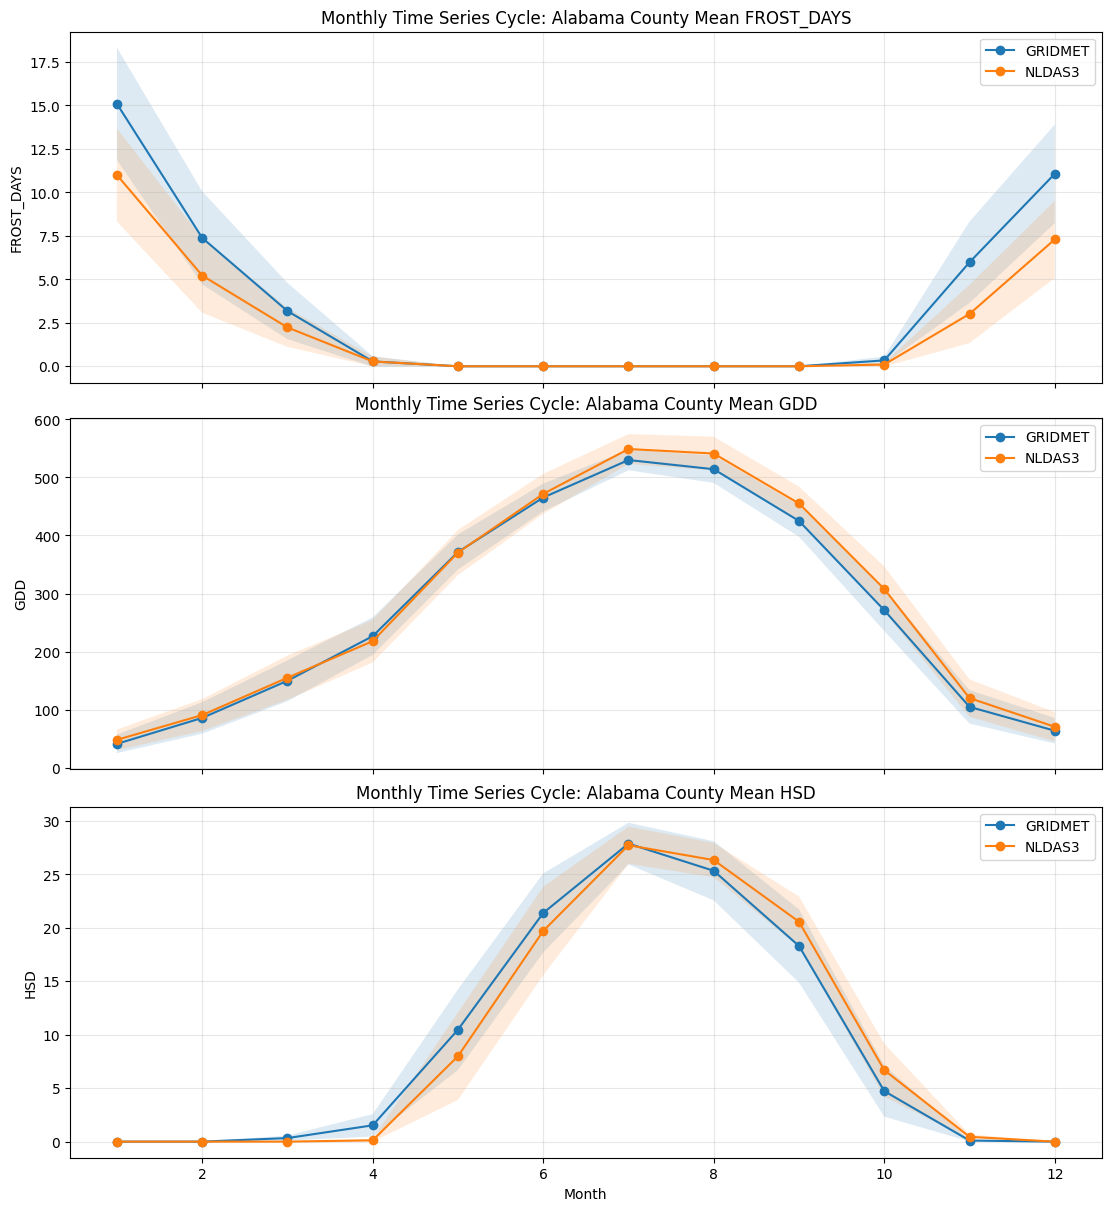

,month,gridmet_mean,nldas3_mean,gridmet_sd,nldas3_sd,variable
0,1,15.094609,11.001723,3.232259,2.676205,frost_days
1,2,7.385561,5.220443,2.674545,2.139552,frost_days
2,3,3.176973,2.233475,1.618533,1.120447,frost_days
3,4,0.278980,0.277290,0.300903,0.278950,frost_days
4,5,0.000000,0.000000,0.000000,0.000000,frost_days
5,6,0.000000,0.000000,0.000000,0.000000,frost_days
6,7,0.000000,0.000000,0.000000,0.000000,frost_days
7,8,0.000000,0.000000,0.000000,0.000000,frost_days
8,9,0.000000,0.000000,0.000000,0.000000,frost_days
9,10,0.339035,0.098924,0.222033,0.117298,frost_days


In [33]:
# ------------------------------
# Monthly time-series cycle (statewide county average) for all variables
# ------------------------------
variable_stems_cycle = sorted({
    c.replace("gridmet_", "").replace("_mean", "")
    for c in df.columns
    if c.startswith("gridmet_") and c.endswith("_mean") and f"nldas3_{c.replace('gridmet_', '')}" in df.columns
})

cycle_results = {}
n_vars = len(variable_stems_cycle)
fig, axes = plt.subplots(n_vars, 1, figsize=(11, 4 * n_vars), sharex=True, constrained_layout=True)
if n_vars == 1:
    axes = [axes]

for ax, var in zip(axes, variable_stems_cycle):
    g_col = f"gridmet_{var}_mean"
    n_col = f"nldas3_{var}_mean"

    cycle_var = df.groupby("month", as_index=False).agg(
        gridmet_mean=(g_col, "mean"),
        nldas3_mean=(n_col, "mean"),
        gridmet_sd=(g_col, "std"),
        nldas3_sd=(n_col, "std"),
    )

    ax.plot(cycle_var["month"], cycle_var["gridmet_mean"], marker="o", label="GRIDMET")
    ax.plot(cycle_var["month"], cycle_var["nldas3_mean"], marker="o", label="NLDAS3")

    ax.fill_between(
        cycle_var["month"],
        cycle_var["gridmet_mean"] - cycle_var["gridmet_sd"],
        cycle_var["gridmet_mean"] + cycle_var["gridmet_sd"],
        alpha=0.15,
    )
    ax.fill_between(
        cycle_var["month"],
        cycle_var["nldas3_mean"] - cycle_var["nldas3_sd"],
        cycle_var["nldas3_mean"] + cycle_var["nldas3_sd"],
        alpha=0.15,
    )

    ax.set_title(f"Monthly Time Series Cycle: Alabama County Mean {var.upper()}")
    ax.set_ylabel(var.upper())
    ax.grid(True, alpha=0.3)
    ax.legend()

    cycle_results[var] = cycle_var

axes[-1].set_xlabel("Month")
plt.show()

cycle = pd.concat(
    [v.assign(variable=k) for k, v in cycle_results.items()],
    ignore_index=True,
 )
cycle

In [ ]:
# Optional export of county-month comparison table
out_csv = Path("./alabama_county_gridmet_vs_nldas3_gdd.csv")
df.to_csv(out_csv, index=False)
print("Wrote", out_csv)

In [37]:
# ------------------------------
# Batch export: all months x all variables x stats (maps + tables)
# ------------------------------
report_dir = Path("./reports/alabama_gridmet_vs_nldas3")
maps_dir = report_dir / "maps"
tables_dir = report_dir / "tables"
report_dir.mkdir(parents=True, exist_ok=True)
maps_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

# Detect variable stems from dataframe columns, e.g. gdd from gridmet_gdd_mean
variable_stems = sorted({
    c.replace("gridmet_", "").replace("_mean", "")
    for c in df.columns
    if c.startswith("gridmet_") and c.endswith("_mean")
})
variable_stems = [v for v in variable_stems if f"nldas3_{v}_mean" in df.columns]

if len(variable_stems) == 0:
    raise RuntimeError("No matching GRIDMET/NLDAS variable columns found in df.")

print("Variables found:", variable_stems)

summary_rows = []

for var in variable_stems:
    for stat in ["mean", "std"]:
        grid_col = f"gridmet_{var}_{stat}"
        nldas_col = f"nldas3_{var}_{stat}"
        if grid_col not in df.columns or nldas_col not in df.columns:
            continue

        # Use blue sequential ramp for frost-related maps to avoid heat-color confusion.
        seq_cmap = "Blues" if var == "frost_days" else "YlOrRd"

        # Save county-month table for this variable/stat
        var_stat_df = df[["month", "GEOID", "county", grid_col, nldas_col]].copy()
        var_stat_df.to_csv(tables_dir / f"county_month_{var}_{stat}.csv", index=False)

        # Monthly summary + correlation by month
        month_summary = var_stat_df.groupby("month", as_index=False).agg(
            gridmet_mean=(grid_col, "mean"),
            nldas3_mean=(nldas_col, "mean"),
            gridmet_sd=(grid_col, "std"),
            nldas3_sd=(nldas_col, "std"),
        )
        month_summary.to_csv(tables_dir / f"monthly_summary_{var}_{stat}.csv", index=False)

        for month in range(1, 13):
            m_df = df[df["month"] == month].copy()
            map_df = al.merge(m_df, on=["GEOID", "county"], how="left")
            map_df["diff"] = map_df[nldas_col] - map_df[grid_col]

            shared_min = np.nanmin([map_df[grid_col].min(), map_df[nldas_col].min()])
            shared_max = np.nanmax([map_df[grid_col].max(), map_df[nldas_col].max()])
            diff_max_abs = np.nanmax(np.abs(map_df["diff"]))

            fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

            map_df.plot(column=grid_col, ax=axes[0], legend=False, cmap=seq_cmap,
                        vmin=shared_min, vmax=shared_max, edgecolor="black", linewidth=0.2)
            axes[0].set_title(f"GRIDMET {var.upper()} {stat} (Month {month:02d})")
            axes[0].axis("off")

            map_df.plot(column=nldas_col, ax=axes[1], legend=False, cmap=seq_cmap,
                        vmin=shared_min, vmax=shared_max, edgecolor="black", linewidth=0.2)
            axes[1].set_title(f"NLDAS3 {var.upper()} {stat} (Month {month:02d})")
            axes[1].axis("off")

            norm_shared = mpl.colors.Normalize(vmin=shared_min, vmax=shared_max)
            sm_shared = mpl.cm.ScalarMappable(norm=norm_shared, cmap=seq_cmap)
            sm_shared.set_array([])
            cbar_shared = fig.colorbar(sm_shared, ax=[axes[0], axes[1]], fraction=0.035, pad=0.02)
            cbar_shared.set_label(f"{var.upper()} {stat}")

            map_df.plot(column="diff", ax=axes[2], legend=False, cmap="RdBu_r",
                        vmin=-diff_max_abs, vmax=diff_max_abs, edgecolor="black", linewidth=0.2)
            axes[2].set_title(f"NLDAS3 - GRIDMET ({var.upper()} {stat})")
            axes[2].axis("off")
            norm_diff = mpl.colors.Normalize(vmin=-diff_max_abs, vmax=diff_max_abs)
            sm_diff = mpl.cm.ScalarMappable(norm=norm_diff, cmap="RdBu_r")
            sm_diff.set_array([])
            cbar_diff = fig.colorbar(sm_diff, ax=axes[2], fraction=0.05, pad=0.02)
            cbar_diff.set_label("Difference")

            out_png = maps_dir / f"map_{var}_{stat}_month_{month:02d}.png"
            fig.savefig(out_png, dpi=150, bbox_inches="tight")
            plt.close(fig)

        # Overall correlations for var/stat
        valid = var_stat_df[[grid_col, nldas_col]].dropna()
        if len(valid) >= 2:
            p = pearsonr(valid[grid_col], valid[nldas_col])
            s = spearmanr(valid[grid_col], valid[nldas_col])
            pearson_r, pearson_p = p.statistic, p.pvalue
            spearman_rho, spearman_p = s.statistic, s.pvalue
        else:
            pearson_r, pearson_p, spearman_rho, spearman_p = np.nan, np.nan, np.nan, np.nan

        summary_rows.append({
            "variable": var,
            "stat": stat,
            "n_pairs": int(len(valid)),
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_rho": spearman_rho,
            "spearman_p": spearman_p,
        })

summary_all = pd.DataFrame(summary_rows)
summary_all.to_csv(tables_dir / "correlation_summary_all_variables.csv", index=False)
print("Saved outputs to", report_dir)
summary_all

Variables found: ['frost_days', 'gdd', 'hsd']
Saved outputs to reports/alabama_gridmet_vs_nldas3


,variable,stat,n_pairs,pearson_r,pearson_p,spearman_rho,spearman_p
0,frost_days,mean,804,0.985449,0.000000e+00,0.977053,0.000000e+00
1,frost_days,std,804,0.968540,0.000000e+00,0.972439,0.000000e+00
2,gdd,mean,804,0.996450,0.000000e+00,0.996435,0.000000e+00
3,gdd,std,804,0.808727,4.909904e-187,0.806165,5.791855e-185
4,hsd,mean,804,0.985780,0.000000e+00,0.955473,0.000000e+00
5,hsd,std,804,0.903956,4.047261e-298,0.908693,1.692287e-306


In [42]:
# ------------------------------
# Build a shareable markdown + HTML report
# ------------------------------
report_md = report_dir / "report.md"
report_html = report_dir / "report.html"

# Build and save distribution figures (one per variable) for report embedding
value_cols = [
    c for c in df.columns
    if (c.startswith("gridmet_") or c.startswith("nldas3_")) and (c.endswith("_mean") or c.endswith("_std"))
]

dist_df = df.melt(
    id_vars=["month", "GEOID", "county"],
    value_vars=value_cols,
    var_name="series",
    value_name="value",
)
dist_df["dataset"] = np.where(dist_df["series"].str.startswith("gridmet_"), "GRIDMET", "NLDAS3")
dist_df["stat"] = np.where(dist_df["series"].str.endswith("_mean"), "mean", "std")
dist_df["variable"] = (
    dist_df["series"]
    .str.replace("^gridmet_", "", regex=True)
    .str.replace("^nldas3_", "", regex=True)
    .str.replace("_mean$", "", regex=True)
    .str.replace("_std$", "", regex=True)
)

report_variables = sorted(dist_df["variable"].unique())
for var in report_variables:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True, constrained_layout=True)
    sub_mean = dist_df[(dist_df["variable"] == var) & (dist_df["stat"] == "mean")]
    sub_std = dist_df[(dist_df["variable"] == var) & (dist_df["stat"] == "std")]

    sns.boxplot(data=sub_mean, x="month", y="value", hue="dataset", ax=axes[0])
    axes[0].set_title(f"{var.upper()} Mean Distribution by Month")
    axes[0].set_ylabel(f"{var.upper()} mean")
    axes[0].legend(loc="upper right")

    sns.boxplot(data=sub_std, x="month", y="value", hue="dataset", ax=axes[1])
    axes[1].set_title(f"{var.upper()} Std Distribution by Month")
    axes[1].set_ylabel(f"{var.upper()} std")
    axes[1].legend(loc="upper right")

    for ax in axes:
        ax.set_xlabel("Month")

    dist_out = maps_dir / f"distribution_{var}.png"
    fig.savefig(dist_out, dpi=150, bbox_inches="tight")
    plt.close(fig)

# Build and save monthly time-series cycle figures (one per variable)
for var in report_variables:
    mean_long = pd.concat([
        df[["month", f"gridmet_{var}_mean"]].rename(columns={f"gridmet_{var}_mean": "value"}).assign(dataset="GRIDMET"),
        df[["month", f"nldas3_{var}_mean"]].rename(columns={f"nldas3_{var}_mean": "value"}).assign(dataset="NLDAS3"),
    ], ignore_index=True)

    fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
    sns.lineplot(
        data=mean_long,
        x="month", y="value",
        hue="dataset", style="dataset", markers=True, dashes=False,
        errorbar="sd", estimator="mean", ax=ax,
    )
    ax.set_title(f"{var.upper()} Monthly Mean Cycle")
    ax.set_ylabel(f"{var.upper()} mean")
    ax.set_xlabel("Month")
    ax.set_xticks(range(1, 13))
    ax.grid(True, alpha=0.3)

    cycle_out = maps_dir / f"cycle_{var}.png"
    fig.savefig(cycle_out, dpi=150, bbox_inches="tight")
    plt.close(fig)

lines = []
lines.append("# Alabama GRIDMET vs NLDAS3 Comparison Report")
lines.append("")
lines.append("## Indicator Definitions and Method")
lines.append("")
lines.append("- **Growing Degree Days (GDD)**: calculated from daily mean temperature using base threshold **10 deg C**.")
lines.append("  Contribution per day is `max(((Tmax + Tmin)/2 - 10), 0)`. Monthly GDD is the sum of daily contributions.")
lines.append("- **Heat Stress Days (HSD)**: count of days where **Tmax > 30 deg C**.")
lines.append("- **Frost-Free Days**: count of days where **Tmin > 0 deg C**. (Related indicator in this workflow is frost days with threshold **Tmin < 0 deg C**.)")
lines.append("- **Climatology period**: **2016-2025** (10 years).")
lines.append("- **GRIDMET data access**: Google Earth Engine.")
lines.append("- **NLDAS-3 data access**: AWS S3.")
lines.append("")

for var in report_variables:
    lines.append(f"## {var.upper()} Mean Maps")
    lines.append("")
    lines.append("Representative monthly mean maps (months 01, 04, 07, 10):")
    lines.append("")
    for month in [1, 4, 7, 10]:
        img_rel = f"maps/map_{var}_mean_month_{month:02d}.png"
        lines.append(f"### Month {month:02d}")
        lines.append(f"![{var}_mean_{month:02d}]({img_rel})")
        lines.append("")

    lines.append(f"## {var.upper()} Distribution Plots")
    lines.append("")
    lines.append(f"![distribution_{var}](maps/distribution_{var}.png)")
    lines.append("")

    lines.append(f"## {var.upper()} Time Series Cycle")
    lines.append("")
    lines.append(f"![cycle_{var}](maps/cycle_{var}.png)")
    lines.append("")

report_md.write_text("\n".join(lines), encoding="utf-8")

# Minimal HTML render from markdown text, preserving readability in browser
html_lines = [
    "<html><head><meta charset='utf-8'><title>Alabama GRIDMET vs NLDAS3 Report</title>",
    "<style>body{font-family:Arial,sans-serif;max-width:1200px;margin:24px auto;padding:0 12px;} img{max-width:100%;height:auto;border:1px solid #ddd;margin:8px 0;} pre{background:#f6f8fa;padding:10px;border-radius:6px;overflow:auto;}</style>",
    "</head><body>",
]

for ln in lines:
    if ln.startswith("# "):
        html_lines.append(f"<h1>{ln[2:]}</h1>")
    elif ln.startswith("## "):
        html_lines.append(f"<h2>{ln[3:]}</h2>")
    elif ln.startswith("### "):
        html_lines.append(f"<h3>{ln[4:]}</h3>")
    elif ln.startswith("![") and "](" in ln and ln.endswith(")"):
        alt = ln[2:ln.index("](")]
        src = ln[ln.index("](")+2:-1]
        html_lines.append(f"<img alt='{alt}' src='{src}' />")
    elif ln.startswith("- "):
        html_lines.append(f"<p>{ln}</p>")
    elif ln.strip() == "":
        html_lines.append("<br/>")
    else:
        html_lines.append(f"<p>{ln}</p>")

html_lines.append("</body></html>")
report_html.write_text("\n".join(html_lines), encoding="utf-8")

print("Wrote report files:")
print("-", report_md)
print("-", report_html)

Wrote report files:
- reports/alabama_gridmet_vs_nldas3/report.md
- reports/alabama_gridmet_vs_nldas3/report.html


In [17]:
# Diagnostic: why NLDAS county zonal stats are NaN
from shapely.geometry import box

diag_month = 7
nldas_tif = nldas_dir / f"NLDAS3_Climatology_Month_{diag_month:02d}.tif"
gridmet_tif = gridmet_dir / f"GRIDMET_Climatology_Month_{diag_month:02d}.tif"

with rasterio.open(nldas_tif) as src_n:
    n_arr = src_n.read(1)
    n_bounds = box(*src_n.bounds)
    n_crs = src_n.crs
    n_nodata = src_n.nodata
    n_non_null = int(np.sum(np.isfinite(n_arr) & (n_arr != n_nodata)))

with rasterio.open(gridmet_tif) as src_g:
    g_arr = src_g.read(1)
    g_bounds = box(*src_g.bounds)
    g_crs = src_g.crs
    g_nodata = src_g.nodata
    g_non_null = int(np.sum(np.isfinite(g_arr) & (g_arr != g_nodata)))

al_n = al.to_crs(n_crs) if al.crs != n_crs else al
al_g = al.to_crs(g_crs) if al.crs != g_crs else al

print("NLDAS CRS:", n_crs)
print("NLDAS bounds:", tuple(round(v, 4) for v in nldas_tif.stat().st_size and src_n.bounds) if False else "see below")
print("NLDAS bounds:", (n_bounds.bounds))
print("NLDAS nodata:", n_nodata, "non-null pixels:", n_non_null)
print("NLDAS counties intersecting raster:", int(al_n.geometry.intersects(n_bounds).sum()), "of", len(al_n))

print("GRIDMET CRS:", g_crs)
print("GRIDMET bounds:", (g_bounds.bounds))
print("GRIDMET nodata:", g_nodata, "non-null pixels:", g_non_null)
print("GRIDMET counties intersecting raster:", int(al_g.geometry.intersects(g_bounds).sum()), "of", len(al_g))

NLDAS CRS: EPSG:4326
NLDAS bounds: see below
NLDAS bounds: (-88.49999511015771, 30.0999995405545, -84.80000031220558, 35.10000122238496)
NLDAS nodata: None non-null pixels: 178447
NLDAS counties intersecting raster: 67 of 67
GRIDMET CRS: EPSG:4326
GRIDMET bounds: (-88.50202179145526, 30.07559571232158, -84.76503020951806, 35.1061613033909)
GRIDMET nodata: None non-null pixels: 14023
GRIDMET counties intersecting raster: 67 of 67
